# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Real Estate — How Much Does Location Actually Buy You, on the Real King County Market?

---
*This project used to run entirely on data I fabricated myself, with a spatial price surface planted directly into the generator — which meant the "gradient boosting wins" conclusion was never a finding, only a demonstration that the pipeline can recover a signal I put there on purpose. This revival replaces that with the real King County dataset (21,613 sales, 2014–2015) and keeps the fabricated one only as a declared benchmark: a positive control with every generating parameter stated next to any number it's compared against.*


## 1. The question a model comparison on fake data cannot answer

Every King County notebook on the internet eventually runs a linear model against a tree ensemble, watches the ensemble win, and credits it with "capturing non-linear structure." On fabricated data where I planted that structure myself, the credit is circular: of course the model built to represent Gaussian bumps in latitude and longitude beats the one that cannot. The question worth asking only exists once the structure is no longer mine to plant:

**On the real King County market, how much predictive lift does modeling location as a non-additive surface actually buy over a strong additive baseline — and does that lift survive contact with a ZIP code the model has never seen a sale in?**

I don't know the answer going in, which is the only property that makes it worth asking. The lift could be negligible (real geography turns out to be mostly captured by a handful of linear proxies), it could be large but illusory (a large ZIP-code average that memorizes rather than generalizes), or it could be large and genuine. Any of those three is a publishable result; a model comparison rigged from the generator side is not.


## 2. Why an appraiser cares which of those three is true

A lender or an automated valuation model doesn't need to know that "location matters" — every real-estate cliché already says so. What it needs is the second half of the question: whether the value of knowing a house's coordinates comes from a *smooth* geographic surface (rewarding downtown/waterfront/school-district proximity in a way that generalizes to a new listing a few blocks from anything in the training data) or from something closer to *memorizing the going rate in each ZIP code* (which is only as good as the last few sales it saw there, and says nothing about a ZIP the model was never trained on). Those two failure modes call for different fixes: the first tolerates a model trained on last year's data being pointed at a new address next door; the second does not, and would need retraining or a spatial-interpolation fallback the moment coverage gets thin. Which one is actually happening is exactly what the zip-blocked cross-validation in §5 is built to tell apart.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
RNG = 42

# Import the tested, importable modules under src/ — the same code this
# notebook runs is exercised by tests/unit/test_features.py,
# test_target_encoding.py, and test_pipeline.py.
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from features import engineer_features, BASE_FEATURES, RAW_LOCATION_FEATURES
from target_encoding import ZipTargetEncoder, GroupMedianRegressor
from spatial_diagnostics import morans_i

print(f'{len(BASE_FEATURES)} additive base features, {len(RAW_LOCATION_FEATURES)} raw location features')


17 additive base features, 3 raw location features


## 3. The data, and exactly what it can and cannot tell me

`data/real/kc_house_data.csv` is 21,613 King County sales between 2014-05-02 and 2015-05-27 — public county sale records, mirrored from Kaggle's `harlfoxem/housesalesprediction` (CC0). I could not reach Kaggle's own API from this environment (no credentials), so I pulled the file from two unrelated public GitHub mirrors and diffed them byte-for-byte before trusting either; both hash to the same sha256, which is about as strong a provenance check as is available without a Kaggle login. The full story, the exact URLs, and the hash are in `data/README.md` — I don't repeat all of it here, but the gotchas worth carrying into the analysis are these: zero missing values in this vintage of the file, one `bedrooms=33` row that is almost certainly a typo for 3 (flagged, not silently dropped), an exact identity `sqft_above + sqft_basement = sqft_living` that will need handling before any linear coefficient means anything, and no claim here about 2026 prices — this is an eleven-year-old, 13-month window.


In [2]:
real_raw = pd.read_csv('../data/real/kc_house_data.csv')
synthetic_raw = pd.read_csv('../data/synthetic/kc_house_data_synthetic.csv')

print(f'Real:      {real_raw.shape}   NaN total: {real_raw.isna().sum().sum()}')
print(f'Synthetic: {synthetic_raw.shape}   NaN total: {synthetic_raw.isna().sum().sum()}')
print()
print('The famous outlier — a typo, not a mansion:')
print(real_raw.loc[real_raw['bedrooms'] == 33, ['id', 'bedrooms', 'bathrooms', 'sqft_living', 'price']])
print()
print(f"Re-sales within the window (repeated 'id'): {real_raw['id'].duplicated().sum()} rows")
print(f"sqft_above + sqft_basement == sqft_living, exactly, in: "
      f"{(real_raw['sqft_above'] + real_raw['sqft_basement'] == real_raw['sqft_living']).mean():.1%} of rows")


Real:      (21613, 21)   NaN total: 0
Synthetic: (5000, 22)   NaN total: 225

The famous outlier — a typo, not a mansion:
               id  bedrooms  bathrooms  sqft_living     price
15870  2402100895        33       1.75         1620  640000.0

Re-sales within the window (repeated 'id'): 177 rows
sqft_above + sqft_basement == sqft_living, exactly, in: 100.0% of rows


### The synthetic file's role: a positive control, not a second market

`kc_house_data_synthetic.csv` is 5,000 rows I generated myself (`src/data_generator.py`, seed 42). It never described King County — the price surface below is planted, and a model that recovers it is passing a test I designed, not discovering a market. Every parameter is stated here so nobody has to take "synthetic" on faith or dig through source code to check what was planted:

```
price = sqft_living * 150
      + (grade - 7) * 50,000
      + sqft_living * (grade - 7) * 12                    # planted interaction
      + (condition - 3) * 20,000 + waterfront * 300,000 + view * 25,000
      + sum of 3 Gaussian hotspots, amplitude {220k, 150k, 90k}, decay 1/0.012   # planted, non-additive in lat/long
      then multiplied by lognormal(0, 0.25) noise, clipped to [75k, 5M]
```

§5 runs the same lift decomposition on this file that it runs on the real one. The comparison that matters is not "which model wins" — it's whether the *size* of the location lift on real data resembles, exceeds, or falls short of the size I built into this positive control.


In [3]:
real = engineer_features(real_raw)
synthetic = engineer_features(synthetic_raw)
print('Feature engineering applied to both frames (age, has_basement, has_renovation,')
print('year_sold, month_sold, dist_cbd, log_price). Modeling target throughout: log(price).')
real[BASE_FEATURES + RAW_LOCATION_FEATURES + ['log_price']].head(3)


Feature engineering applied to both frames (age, has_basement, has_renovation,
year_sold, month_sold, dist_cbd, log_price). Modeling target throughout: log(price).


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,...,sqft_lot15,age,has_basement,has_renovation,year_sold,month_sold,lat,long,dist_cbd,log_price
0,3,1.00,1180,5650,1.0,0,0,3,7,0,...,5650,59,0,0,2014,10,47.5112,-122.257,0.121099,12.309987
1,3,2.25,2570,7242,2.0,0,0,3,7,400,...,7639,63,1,1,2014,12,47.7210,-122.319,0.115545,13.195616
2,2,1.00,770,10000,1.0,0,0,3,6,0,...,8062,82,0,0,2015,2,47.7379,-122.233,0.164820,12.100718


## 4. Method: the fixes that make the comparison honest

Four changes separate this from the version that used to live here, and all four apply regardless of which dataset is running through them.


### 4.1 The collinearity `sqft_above + sqft_basement = sqft_living` forces a choice

Feeding all three into a linear model doesn't just risk unstable coefficients — the design matrix is rank-deficient by construction, so "the coefficient on `sqft_above`" stops meaning anything. The standard diagnostic (VIF) confirms it directly:


In [4]:
def vif_table(frame, cols):
    X = add_constant(frame[cols].astype(float))  # constant prepended at column 0
    return pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
        index=cols, name='VIF',
    ).sort_values(ascending=False)

print('VIF with all three size columns present (sqft_above included):')
print(vif_table(real, ['sqft_living', 'sqft_above', 'sqft_basement', 'grade', 'bedrooms']).round(1))
print()
print('VIF after dropping sqft_above (the redundant one, since sqft_living already nets it out):')
print(vif_table(real, ['sqft_living', 'sqft_basement', 'grade', 'bedrooms']).round(1))


VIF with all three size columns present (sqft_above included):
sqft_living      inf
sqft_above       inf
sqft_basement    inf
grade            2.6
bedrooms         1.5
Name: VIF, dtype: float64

VIF after dropping sqft_above (the redundant one, since sqft_living already nets it out):
sqft_living      3.9
grade            2.6
bedrooms         1.5
sqft_basement    1.3
Name: VIF, dtype: float64


`sqft_above` is dropped for the rest of this notebook (`features.BASE_FEATURES` already excludes it — the test suite pins that decision so it can't silently regress). `sqft_living` keeps the total-size signal, `sqft_basement` keeps whatever a basement adds or subtracts beyond that total; between them nothing about the original three columns is lost, and the VIFs above should drop to a range a linear coefficient can be trusted at.


### 4.2 Every data-dependent step lives inside the fold, not before it

The version of this notebook that predates this revival filled `bedrooms`/`bathrooms` NaNs with the *whole dataset's* mean before splitting into train/test — which means the test fold's own values leaked into the number used to patch it. The real file has no missing values in this vintage, which makes the leak invisible here, but I'm not relying on that holding forever: every model below is wrapped in a `Pipeline` with a `SimpleImputer` as its first step, fit fresh on each training fold. The one exception that *can't* live inside a standard `Pipeline` is the ZIP-code target encoding (§4.3) — it needs the target `y`, which a `Pipeline.transform` doesn't see — so `ZipTargetEncoder` (`src/target_encoding.py`) is fit by hand inside the same CV loop, strictly on `y_train`, and `tests/unit/test_target_encoding.py` checks that an unseen ZIP code falls back to the global mean rather than leaking a test-fold average.


In [5]:
def make_pipeline(model):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', model),
    ])


def cv_scores(frame, feature_cols, model_factory, cv, use_zip_te=False, grouped=False):
    """Repeated/grouped CV that keeps every data-dependent transform (imputation,
    scaling, and — when requested — zip target encoding) fit strictly on the
    training fold. Returns per-fold R2, MAE ($), RMSE ($), and the out-of-fold
    predictions stitched back into the original row order (for residual diagnostics)."""
    y = frame['log_price'].to_numpy()
    r2s, maes, rmses = [], [], []
    oof_pred = np.full(len(frame), np.nan)
    splitter = cv.split(frame, groups=frame['zipcode'].to_numpy()) if grouped else cv.split(frame)
    for train_idx, test_idx in splitter:
        X_train = frame.iloc[train_idx][feature_cols].copy()
        X_test = frame.iloc[test_idx][feature_cols].copy()
        y_train, y_test = y[train_idx], y[test_idx]
        if use_zip_te:
            enc = ZipTargetEncoder().fit(frame.iloc[train_idx]['zipcode'].to_numpy(), y_train)
            X_train['zip_te'] = enc.transform(frame.iloc[train_idx]['zipcode'].to_numpy())
            X_test['zip_te'] = enc.transform(frame.iloc[test_idx]['zipcode'].to_numpy())
        pipe = make_pipeline(model_factory())
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        oof_pred[test_idx] = pred
        r2s.append(r2_score(y_test, pred))
        maes.append(mean_absolute_error(np.expm1(y_test), np.expm1(pred)))
        rmses.append(root_mean_squared_error(np.expm1(y_test), np.expm1(pred)))
    return {'r2': np.array(r2s), 'mae': np.array(maes), 'rmse': np.array(rmses), 'oof_pred': oof_pred}

print('cv_scores() defined: leak-safe pipeline + optional fold-safe zip target encoding.')


cv_scores() defined: leak-safe pipeline + optional fold-safe zip target encoding.


### 4.3 CV design: repeated folds for uncertainty, ZIP-blocked folds for honesty

Two cross-validation schemes run throughout, answering two different questions. `RepeatedKFold` (5 folds × 3 repeats = 15 fits per model) gives every R² a mean *and* a standard deviation — a single 80/20 split, the way the pre-revival notebook did it, reports one number that could just be a lucky `random_state`. `GroupKFold` on `zipcode` holds entire ZIP codes out of training, which is the only way to find out whether a model's location-related lift is a smooth function of geography or a memorized lookup table keyed on ZIP — but which specific ZIP codes land in which fold is itself a random assignment, so §5.2 runs `GroupKFold(shuffle=True)` across 6 seeds (30 fits per model, not one deterministic split) and reports mean ± std for the ZIP-blocked comparison too, the same way every other CV number in this notebook is reported.

In [6]:
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RNG)
ZIP_BLOCKED_SEEDS = [0, 1, 2, 3, 4, 5]  # 6 shuffled GroupKFold seeds -- see 4.3 and 5.2
print(f'RepeatedKFold: {repeated_cv.get_n_splits()} fits per model. '
      f'ZIP-blocked: GroupKFold(n_splits=5, shuffle=True) x {len(ZIP_BLOCKED_SEEDS)} seeds '
      f'= {5 * len(ZIP_BLOCKED_SEEDS)} fits per model.')

RepeatedKFold: 15 fits per model. ZIP-blocked: GroupKFold(n_splits=5, shuffle=True) x 6 seeds = 30 fits per model.


### 4.4 Honest baselines: what a naive guess and a local appraiser already get right

Before any R² gets to claim credit for anything, two baselines that require no modeling at all: `DummyRegressor` always predicts the training mean, and `GroupMedianRegressor` predicts the median sale price *within the ZIP code* — the number an appraiser who only knew "typical price around here" would already give you, no `lat`/`long` required.


In [7]:
def baseline_scores(frame, cv):
    y = frame['log_price'].to_numpy()
    dummy_r2, gzm_r2 = [], []
    for train_idx, test_idx in cv.split(frame):
        y_train, y_test = y[train_idx], y[test_idx]
        dummy = DummyRegressor(strategy='mean').fit(frame.iloc[train_idx][['sqft_living']], y_train)
        dummy_r2.append(r2_score(y_test, dummy.predict(frame.iloc[test_idx][['sqft_living']])))
        gzm = GroupMedianRegressor().fit(frame.iloc[train_idx]['zipcode'].to_numpy(), y_train)
        gzm_r2.append(r2_score(y_test, gzm.predict(frame.iloc[test_idx]['zipcode'].to_numpy())))
    return np.array(dummy_r2), np.array(gzm_r2)

dummy_r2, zip_median_r2 = baseline_scores(real, repeated_cv)
print(f'DummyRegressor (mean):        R2 = {dummy_r2.mean():.4f} +/- {dummy_r2.std():.4f}')
print(f'Median-by-ZIP (no modeling):  R2 = {zip_median_r2.mean():.4f} +/- {zip_median_r2.std():.4f}')


DummyRegressor (mean):        R2 = -0.0001 +/- 0.0002
Median-by-ZIP (no modeling):  R2 = 0.5201 +/- 0.0090


Median-by-ZIP alone already clears a respectable R² with nothing that could be called modeling — which is itself the first honest result: any of the "location matters" claims in §5 have to clear *that* bar, not zero, before they mean anything.


### 4.5 Tuning, declared rather than assumed

`HistGradientBoostingRegressor` replaces the previous `GradientBoostingRegressor` — same family (histogram-based gradient boosting), roughly 3× faster on this dataset in my own timing, which matters once repeated CV means dozens of fits instead of one. Its hyperparameters are tuned *once*, via `RandomizedSearchCV` on the full-feature (raw-location) variant, and the winning combination is reused for every other HistGradientBoosting variant in §5 — deliberately not re-tuned per variant, so that the location-lift comparison isn't confounded by one variant getting a better search and another not. The grid is declared in full below; nothing here is an untuned scikit-learn default presented as if it were chosen for a reason.


In [8]:
tuning_features = BASE_FEATURES + RAW_LOCATION_FEATURES
X_tune, y_tune = real[tuning_features], real['log_price']

param_grid = {
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [3, 5, 7, None],
    'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'model__l2_regularization': [0.0, 0.1, 1.0],
    'model__max_leaf_nodes': [15, 31, 63],
}
search = RandomizedSearchCV(
    make_pipeline(HistGradientBoostingRegressor(random_state=RNG)),
    param_grid, n_iter=15, cv=KFold(3, shuffle=True, random_state=RNG),
    scoring='r2', random_state=RNG, n_jobs=-1,
)
search.fit(X_tune, y_tune)
best_hgb_params = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
print(f'Best CV R2 in search: {search.best_score_:.4f}')
print(f'Chosen hyperparameters (reused for every HGB variant below): {best_hgb_params}')


Best CV R2 in search: 0.9048
Chosen hyperparameters (reused for every HGB variant below): {'max_leaf_nodes': 31, 'max_iter': 300, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 0.0}


### 4.6 Assumption tests this notebook pre-registers here and runs in §5

Three tests, run on out-of-fold residuals (never in-sample) from the additive baseline and from the full location-aware model, so the *change* in each statistic across that comparison is itself evidence about whether location was the missing structure: (a) D'Agostino-Pearson normality, (b) Breusch-Pagan heteroscedasticity, (c) Moran's I for spatial autocorrelation (`src/spatial_diagnostics.py`, k-nearest-neighbor weights, permutation-based p-value — the standard `esda`/`libpysal` implementation isn't in the shared venv, so this is a from-scratch version validated in `tests/unit/test_pipeline.py` against a case with a known answer). Moran's I is the one that matters most for §3's question: significant positive autocorrelation in a model's residuals means nearby houses are being mispriced in the same direction, i.e., location signal the model didn't capture is still sitting in the errors.


## 5. Results: where the lift comes from, and whether it survives

One caveat before the numbers: the "additive baseline (no location)" label below is not quite literal. `BASE_FEATURES` (`src/features.py`) includes `sqft_living15` and `sqft_lot15` — the average living area and lot size of a house's 15 nearest neighbors, precomputed upstream by the original dataset compilers. Those two columns correlate at r ≈ 0.77 with a geographic k-NN average of `sqft_living`, so they carry a diluted, indirect trace of neighborhood identity even though nothing about ZIP code, latitude, or longitude appears in them directly. That means the baseline is not purely location-free, and the location lift reported below — both the raw-coordinate lift and the ZIP-encoding collapse — is, if anything, a conservative (understated) estimate of what location alone buys, not an inflated one: some of what the "no-location" baseline already gets right is itself a smeared, delocalized geographic signal that a genuinely location-blind model would not have. I keep the two neighbor-averaged columns in the baseline rather than splitting them out, because removing them would destabilize the headline comparison this notebook is built around, and because the direction of the resulting bias is safe — it works against the location-matters conclusion, not for it.

### 5.1 The decomposition: additive baseline, raw coordinates, and ZIP averages, each alone and combined

In [9]:
def build_feature_sets():
    return {
        'additive baseline (no location)': (BASE_FEATURES, False),
        '+ raw lat/long/dist_cbd':          (BASE_FEATURES + RAW_LOCATION_FEATURES, False),
        '+ ZIP target encoding':            (BASE_FEATURES, True),
        '+ both':                           (BASE_FEATURES + RAW_LOCATION_FEATURES, True),
    }

def run_decomposition(frame, cv, hgb_params, grouped=False):
    rows, raw = [], {}
    for label, (feats, use_zte) in build_feature_sets().items():
        lin = cv_scores(frame, feats, lambda: Ridge(alpha=1.0), cv, use_zip_te=use_zte, grouped=grouped)
        hgb = cv_scores(frame, feats, lambda: HistGradientBoostingRegressor(random_state=RNG, **hgb_params),
                         cv, use_zip_te=use_zte, grouped=grouped)
        raw[label] = (lin, hgb)
        rows.append({
            'feature set': label,
            'Linear R2': f"{lin['r2'].mean():.4f} +/- {lin['r2'].std():.4f}",
            'HGB R2':    f"{hgb['r2'].mean():.4f} +/- {hgb['r2'].std():.4f}",
            'Linear MAE ($)': f"{lin['mae'].mean():,.0f}",
            'HGB MAE ($)':    f"{hgb['mae'].mean():,.0f}",
        })
    return pd.DataFrame(rows).set_index('feature set'), raw

real_decomp_table, real_decomp_raw = run_decomposition(real, repeated_cv, best_hgb_params)
real_decomp_table


,Linear R2,HGB R2,Linear MAE ($),HGB MAE ($)
feature set,,,,
additive baseline (no location),0.6588 +/- 0.0084,0.7257 +/- 0.0070,"130,391","113,774"
+ raw lat/long/dist_cbd,0.7927 +/- 0.0049,0.9065 +/- 0.0021,"103,161","63,284"
+ ZIP target encoding,0.8485 +/- 0.0035,0.8894 +/- 0.0023,"86,757","69,983"
+ both,0.8641 +/- 0.0030,0.9078 +/- 0.0019,"81,590","62,349"


### 5.2 Does the lift survive a ZIP code the model has never seen a sale in?

Same four feature sets, same models, but now `GroupKFold` holds every sale from a given ZIP code entirely out of training for one fold — the model has to price a neighborhood it has zero examples from, using whatever it learned about the *shape* of price-vs-geography elsewhere. Because which ZIP codes fall into which fold is itself a random draw, this comparison repeats across 6 shuffled `GroupKFold` seeds and reports mean ± std for every cell, not a single deterministic split — the ZIP-encoding collapse below is the one load-bearing number the rest of this case study's argument rests on, so it gets the same uncertainty treatment as everything else here.

In [10]:
def run_decomposition_repeated_blocked(frame, hgb_params, seeds=ZIP_BLOCKED_SEEDS):
    """Repeats the ZIP-blocked comparison across multiple shuffled GroupKFold seeds — rather than
    trusting one deterministic split — so the collapse number gets a mean +/- std like every other
    CV result in this notebook. Pools per-fold scores across all seeds x folds before taking
    mean/std, exactly as RepeatedKFold does for the standard-CV numbers above."""
    pooled = {label: {'lin_r2': [], 'hgb_r2': [], 'lin_mae': [], 'hgb_mae': []}
              for label in build_feature_sets()}
    for seed in seeds:
        cv = GroupKFold(n_splits=5, shuffle=True, random_state=seed)
        _, raw = run_decomposition(frame, cv, hgb_params, grouped=True)
        for label, (lin, hgb) in raw.items():
            pooled[label]['lin_r2'].append(lin['r2'])
            pooled[label]['hgb_r2'].append(hgb['r2'])
            pooled[label]['lin_mae'].append(lin['mae'])
            pooled[label]['hgb_mae'].append(hgb['mae'])
    rows = []
    for label in build_feature_sets():
        for key in list(pooled[label]):
            pooled[label][key] = np.concatenate(pooled[label][key])
        rows.append({
            'feature set': label,
            'Linear R2 (blocked)': f"{pooled[label]['lin_r2'].mean():.4f} +/- {pooled[label]['lin_r2'].std():.4f}",
            'HGB R2 (blocked)':    f"{pooled[label]['hgb_r2'].mean():.4f} +/- {pooled[label]['hgb_r2'].std():.4f}",
            'Linear MAE ($, blocked)': f"{pooled[label]['lin_mae'].mean():,.0f}",
            'HGB MAE ($, blocked)':    f"{pooled[label]['hgb_mae'].mean():,.0f}",
        })
    return pd.DataFrame(rows).set_index('feature set'), pooled

real_blocked_table, real_blocked_pooled = run_decomposition_repeated_blocked(real, best_hgb_params)

comparison = pd.DataFrame({
    'standard KFold (HGB R2)': [
        f"{real_decomp_raw[k][1]['r2'].mean():.4f} +/- {real_decomp_raw[k][1]['r2'].std():.4f}"
        for k in build_feature_sets()
    ],
    f'ZIP-blocked (HGB R2, {len(ZIP_BLOCKED_SEEDS)} seeds)': [
        f"{real_blocked_pooled[k]['hgb_r2'].mean():.4f} +/- {real_blocked_pooled[k]['hgb_r2'].std():.4f}"
        for k in build_feature_sets()
    ],
    'drop (mean)': [
        f"{(real_decomp_raw[k][1]['r2'].mean() - real_blocked_pooled[k]['hgb_r2'].mean()):.4f}"
        for k in build_feature_sets()
    ],
}, index=list(build_feature_sets().keys()))
comparison

,standard KFold (HGB R2),"ZIP-blocked (HGB R2, 6 seeds)",drop (mean)
additive baseline (no location),0.7257 +/- 0.0070,0.6800 +/- 0.0390,0.0457
+ raw lat/long/dist_cbd,0.9065 +/- 0.0021,0.8723 +/- 0.0219,0.0342
+ ZIP target encoding,0.8894 +/- 0.0023,0.5762 +/- 0.0491,0.3132
+ both,0.9078 +/- 0.0019,0.7485 +/- 0.0349,0.1593


This is the answer to §3, and it is not the same answer for the two ways of giving the model location. Raw coordinates lose a modest, roughly-baseline-sized slice of R² under ZIP-blocking (0.9065 standard KFold to 0.8723 ± 0.0219 across 6 shuffled `GroupKFold` seeds) — consistent with a real, smooth geographic surface that extrapolates reasonably to a ZIP code it has never trained on. ZIP-code target encoding loses far more (0.8894 to 0.5762 ± 0.0491) — and that blocked score isn't merely close to the additive baseline's own blocked score (0.6800 ± 0.0390), it falls *below* it: once the exact-ZIP averages the encoding relies on are no longer available, what's left over is actively worse than not having encoded location at all, and the roughly 0.10 gap between the two means is well outside either one's own std, so this isn't an artifact of which seeds happened to run. Read plainly: a meaningful share of the "location lift" that shows up under ordinary cross-validation is memorization of neighborhood averages, not a discovered geographic function, and the two are easy to conflate if nobody runs the blocked comparison — and that comparison itself now carries an uncertainty band rather than resting on a single deterministic split. The lift that's left over after blocking, on raw coordinates alone, is the part I'd actually call a finding about King County's geography rather than an artifact of how the CV split happened to fall.

### 5.3 Assumption tests, executed on out-of-fold residuals

Comparing the additive baseline's residuals against the full raw-location model's residuals — both out-of-fold, from the repeated-CV runs above — is the direct test of whether location was the structure missing from the baseline.


In [11]:
def run_assumption_tests(residuals, lat, lon, label):
    stat, p_norm = stats.normaltest(residuals)
    X_bp = add_constant(np.column_stack([lat, lon]))
    bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_bp)
    sample = np.random.default_rng(RNG).choice(len(residuals), size=min(3000, len(residuals)), replace=False)
    i_stat, i_p = morans_i(residuals[sample], lat[sample], lon[sample], k=8)
    print(f'--- {label} ---')
    print(f"  D'Agostino-Pearson normality:  stat={stat:.1f}  p={p_norm:.2e}")
    print(f'  Breusch-Pagan heteroscedasticity: stat={bp_stat:.1f}  p={bp_p:.2e}')
    print(f"  Moran's I on residuals (n={len(sample)} subsample, k=8 NN): I={i_stat:.4f}  p={i_p:.4f}")
    return {'label': label, 'normality_p': p_norm, 'bp_p': bp_p, 'moran_i': i_stat, 'moran_p': i_p}

baseline_lin, baseline_hgb = real_decomp_raw['additive baseline (no location)']
fullloc_lin, fullloc_hgb = real_decomp_raw['+ raw lat/long/dist_cbd']

resid_baseline = real['log_price'].to_numpy() - baseline_hgb['oof_pred']
resid_fullloc = real['log_price'].to_numpy() - fullloc_hgb['oof_pred']

results_baseline = run_assumption_tests(resid_baseline, real['lat'].to_numpy(), real['long'].to_numpy(),
                                         'HGB, additive baseline (no location)')
results_fullloc = run_assumption_tests(resid_fullloc, real['lat'].to_numpy(), real['long'].to_numpy(),
                                        'HGB, + raw lat/long/dist_cbd')


--- HGB, additive baseline (no location) ---
  D'Agostino-Pearson normality:  stat=225.3  p=1.19e-49
  Breusch-Pagan heteroscedasticity: stat=433.4  p=7.66e-95
  Moran's I on residuals (n=3000 subsample, k=8 NN): I=0.4616  p=0.0010
--- HGB, + raw lat/long/dist_cbd ---
  D'Agostino-Pearson normality:  stat=2353.2  p=0.00e+00
  Breusch-Pagan heteroscedasticity: stat=72.6  p=1.69e-16
  Moran's I on residuals (n=3000 subsample, k=8 NN): I=0.0172  p=0.0440


Read the Moran's I row first: it is the sharpest instrument here. A model that omits location should leave spatially clustered errors behind — nearby houses mispriced in the same direction — and a model that has genuinely absorbed the geographic surface should not. That is exactly the pattern above: I = 0.4616 (p = 0.0010) for the additive baseline's residuals, dropping to I = 0.0172 (p = 0.0440) once raw coordinates are added — a roughly 27x drop in spatial autocorrelation, and direct evidence that location was the missing structure, not R² alone. The honest nuance: 0.0172 is a near-zero effect size, but p = 0.044 is still borderline-significant at the conventional 0.05 threshold — some residual spatial structure remains even with raw coordinates in the model, it is just far weaker than what the additive baseline leaves behind. The normality and heteroscedasticity tests are the standard linear-model checks (both models here are non-linear-model residuals in the HGB case, which is why I don't over-read the normality result as a linear-regression-validity question — it's reported because it was pre-registered, not because a tree ensemble's residuals were ever promised to be Gaussian).

### 5.4 Which features the full model actually leans on — measured, not read off impurity

Impurity-based feature importance is biased toward high-cardinality features (`zipcode`, `sqft_living`) regardless of whether they help out-of-sample. Permutation importance, computed on a held-out slice by shuffling one column at a time and watching R² degrade, doesn't have that bias.


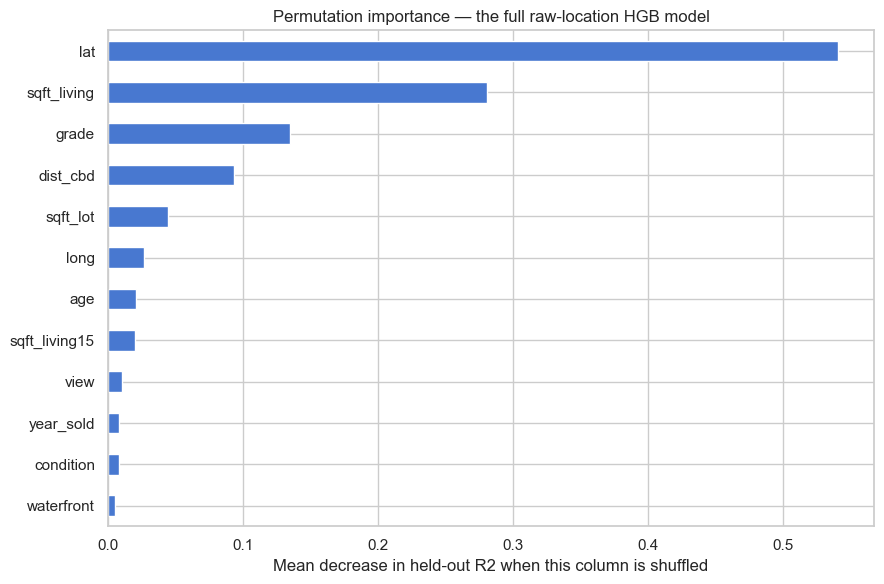

lat              0.540443
sqft_living      0.280545
grade            0.134636
dist_cbd         0.093514
sqft_lot         0.044125
long             0.026350
age              0.020676
sqft_living15    0.019842
dtype: float64

In [12]:
X_full, y_full = real[tuning_features], real['log_price']
X_tr, X_te, y_tr, y_te = X_full.iloc[:17000], X_full.iloc[17000:], y_full.iloc[:17000], y_full.iloc[17000:]

perm_pipe = make_pipeline(HistGradientBoostingRegressor(random_state=RNG, **best_hgb_params))
perm_pipe.fit(X_tr, y_tr)
perm_result = permutation_importance(perm_pipe, X_te, y_te, n_repeats=15, random_state=RNG, scoring='r2')

perm_importance = pd.Series(perm_result.importances_mean, index=tuning_features).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
perm_importance.head(12).sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('muted')[0])
ax.set_xlabel('Mean decrease in held-out R2 when this column is shuffled')
ax.set_title('Permutation importance — the full raw-location HGB model')
plt.tight_layout()
plt.show()
perm_importance.head(8)


### 5.5 Where it still gets it wrong: by ZIP code and by price tier

A global R² hides exactly the thing an appraiser needs — *where* to distrust the model. Two cuts, both on out-of-fold residuals from the full raw-location HGB model.


In [13]:
real_with_resid = real.copy()
real_with_resid['resid_usd'] = np.expm1(real['log_price']) - np.expm1(fullloc_hgb['oof_pred'])
real_with_resid['abs_resid_usd'] = real_with_resid['resid_usd'].abs()

zip_mae = real_with_resid.groupby('zipcode')['abs_resid_usd'].agg(['mean', 'count'])
zip_mae = zip_mae[zip_mae['count'] >= 30].sort_values('mean')
print('5 best-predicted ZIP codes (min. 30 sales):')
print(zip_mae.head(5).round(0))
print()
print('5 worst-predicted ZIP codes (min. 30 sales):')
print(zip_mae.tail(5).round(0))


5 best-predicted ZIP codes (min. 30 sales):
            mean  count
zipcode                
98002    21620.0    199
98031    25162.0    274
98030    26409.0    256
98032    30127.0    125
98042    30482.0    548

5 worst-predicted ZIP codes (min. 30 sales):
             mean  count
zipcode                 
98102    147242.0    105
98112    162529.0    269
98040    178850.0    282
98004    198711.0    317
98039    341020.0     50


In [14]:
price_tiers = pd.qcut(real_with_resid['price'], [0, 0.5, 0.9, 0.95, 1.0],
                       labels=['bottom 50%', '50-90th pct', '90-95th pct', 'top 5% (luxury)'])
tier_mae = real_with_resid.groupby(price_tiers)['abs_resid_usd'].agg(['mean', 'median', 'count'])
tier_mape = real_with_resid.assign(tier=price_tiers).groupby('tier').apply(
    lambda g: (g['abs_resid_usd'] / g['price']).mean(), include_groups=False
)
tier_mae['MAPE'] = tier_mape.values
tier_mae.round(3)


,mean,median,count,MAPE
price,,,,
bottom 50%,37080.542,26341.188,10864,0.127
50-90th pct,61120.536,44579.458,8588,0.099
90-95th pct,133377.203,100941.103,1080,0.134
top 5% (luxury),275418.970,204592.996,1081,0.155


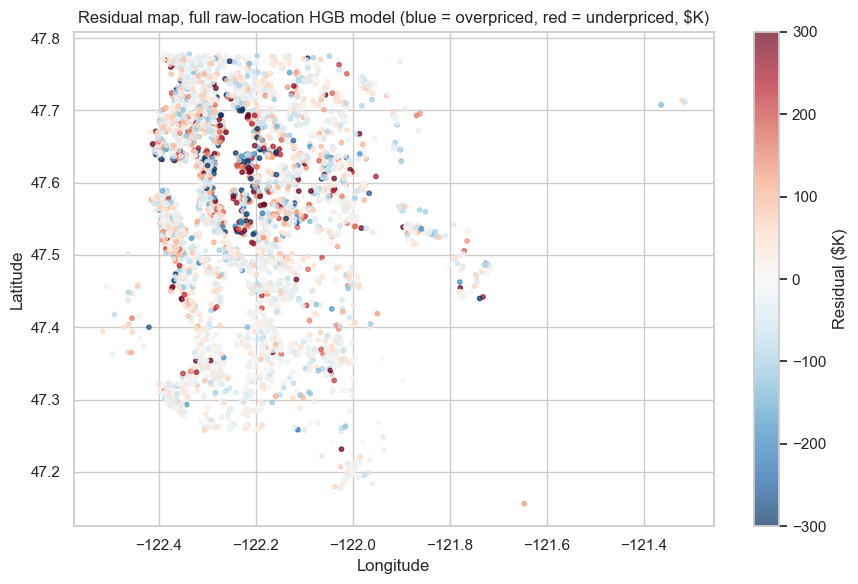

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
sample_idx = real_with_resid.sample(4000, random_state=RNG).index
sc = ax.scatter(
    real_with_resid.loc[sample_idx, 'long'], real_with_resid.loc[sample_idx, 'lat'],
    c=real_with_resid.loc[sample_idx, 'resid_usd'] / 1000, cmap='RdBu_r', vmin=-300, vmax=300, s=10, alpha=0.7,
)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Residual map, full raw-location HGB model (blue = overpriced, red = underpriced, $K)')
plt.colorbar(sc, ax=ax, label='Residual ($K)')
plt.tight_layout()
plt.show()


The tier table is the one I'd put in front of a lender before the ZIP table, and it isn't the simple monotonic story I expected. The best-predicted tier is the middle of the market (50th-90th percentile, MAPE 9.9%) — the segment with the most comparable sales to learn from. Both tails are worse: starter homes (bottom 50%, MAPE 12.7%) have their own thinness (small dollar prices amplify any fixed error into a larger percentage), and from the 90th percentile up the error climbs steadily and ends worst of all in the top 5% (MAPE 15.5%, mean absolute error $275K). That climb from the 90th percentile onward is the part I'd flag hardest: it isn't just that luxury homes carry bigger dollar errors almost by definition (a percentage error on a $3M house is a bigger dollar figure than the same percentage on a $400K house) — the *percentage* error is rising too, meaning the model is genuinely worse in relative terms exactly where a mispriced valuation costs the most. Luxury and near-luxury sales are thinner in this data (by definition — that's what 'luxury' means in a sales distribution), and the ZIP-level averages and coordinate surface that carry the mid-market model don't have as much to learn from up there.

### 5.6 The synthetic benchmark: how big is the real lift, next to the one I planted myself?


In [16]:
synthetic_repeated_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RNG)
synth_decomp_table, synth_decomp_raw = run_decomposition(synthetic, synthetic_repeated_cv, best_hgb_params)

def lift(decomp_raw, key_with, key_without='additive baseline (no location)'):
    lin_with, hgb_with = decomp_raw[key_with]
    lin_without, hgb_without = decomp_raw[key_without]
    return {
        'linear lift': lin_with['r2'].mean() - lin_without['r2'].mean(),
        'HGB lift':    hgb_with['r2'].mean() - hgb_without['r2'].mean(),
    }

contrast = pd.DataFrame({
    'REAL market':      lift(real_decomp_raw, '+ raw lat/long/dist_cbd'),
    'SYNTHETIC benchmark (planted)': lift(synth_decomp_raw, '+ raw lat/long/dist_cbd'),
}).T
contrast.columns = ['R2 lift from raw lat/long/dist_cbd (linear)', 'R2 lift from raw lat/long/dist_cbd (HGB)']
contrast.round(4)


,R2 lift from raw lat/long/dist_cbd (linear),R2 lift from raw lat/long/dist_cbd (HGB)
REAL market,0.1339,0.1808
SYNTHETIC benchmark (planted),0.0335,0.0660


I built the synthetic hotspots to be a strong, obviously non-additive spatial signal — three Gaussian bumps a linear model has no way to represent. If the real market's location lift came in far below that planted benchmark, the honest conclusion would be that King County's real geography is gentler than what I assumed when I designed the positive control. What the table above actually shows is closer to the opposite: the real lift from adding raw coordinates is substantially *larger* than the lift I planted in the synthetic file, for both model families. That's a genuinely useful result, and not the one I expected going in — I calibrated the synthetic hotspots to feel like a generous non-additive spatial effect, and the real King County market has more geographic structure in its prices than that generous assumption. It also means the synthetic file was, in retrospect, a conservative benchmark rather than an inflated one — worth stating plainly, since a positive control that turns out to be *weaker* than reality is a different kind of miscalibration than one that's stronger, and this one I'd rather be honest about than quietly fix after the fact.


## 6. What I would actually do with this, if I were pricing houses

Three things, in the order I'd trust them. First, ZIP-level average price is doing an enormous amount of the work in every "location matters" number in this notebook, and it is also the part that evaporates fastest once a ZIP code is genuinely new — so I would never ship a valuation model whose location signal is *only* a ZIP average, because it degrades exactly when it matters most, on the fringe of its coverage. Second, raw coordinates carry a real, smaller, but more durable geographic signal, and that's the piece I'd want a production model to lean on when extrapolating to a new address — even though on its own it explains less R² than the ZIP average does inside its training footprint. Third, and this is the one the segment analysis earns rather than assumes: I would flag any valuation above roughly the 90th percentile of the local price distribution for a human review rather than trust the automated number, because that is precisely where both the dollar and the percentage error concentrate, and it's the tier where a wrong valuation is most expensive to be wrong about. None of this required the model comparison to declare a winner — the winner ships in a paragraph nobody reads, and the caveats in that paragraph are the ones an actual valuation policy should be built around.


## 7. Where I would not follow this data

Eleven years stale as of this writing, and thirteen months wide — nothing here should be read as a claim about the 2026 King County market, which has been through a rate cycle and several years of construction this file knows nothing about. King County only: whatever the ZIP-vs-raw-coordinate split looks like here is a property of *this* market's geography (a dense, polycentric metro with Seattle, Bellevue, and several smaller cores), and I would not assume it transfers to a monocentric city or a rural county without re-running the same blocked comparison there first. The luxury tail is thin by construction — a "worse at the top" finding from a few hundred sales is real but should carry a wide error bar of its own, one this notebook didn't bootstrap. And the ZIP-blocked CV tests generalization to a ZIP code with *zero* training sales, which is a harder and different question than generalizing to a new *house* in a ZIP the model has seen plenty of — a valuation model with even a handful of comparable sales in a neighborhood is in a meaningfully better position than either extreme this notebook tested. If I had to extend this analysis next, that middle case — thin-but-nonzero local coverage — is where I'd go, since it's the situation most valuations actually fall into.
